# CS F407 - Artificial Intelligence
## Lab 1: Neural Models

**Name:** Eshan Saikia  
**ID:** 2023A7PS1024G

**Notebook role:** executable implementation and experimental evidence.

The written answers and reflections are in the accompanying `neural_models_report.pdf`; this notebook intentionally avoids repeating them.

### Task 1 - Problem specification

XOR sensor rule:

| x1 | x2 | y |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

A single affine layer followed by a sigmoid has a linear decision boundary, so it cannot represent XOR perfectly.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.set_num_threads(1)
SEED = 28
LEARNING_RATE = 0.03
TRAINING_STEPS = 3000
EARLY_STEP = 50

X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y_binary = torch.tensor([[0.],[1.],[1.],[0.]])

print('PyTorch:', torch.__version__)
print('X shape:', tuple(X.shape), '| y shape:', tuple(y_binary.shape))

PyTorch: 2.10.0+cpu
X shape: (4, 2) | y shape: (4, 1)


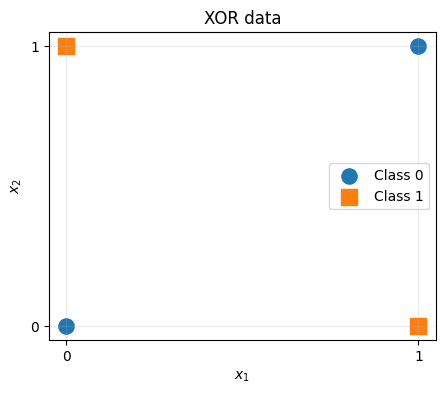

In [2]:
# XOR geometry
plt.figure(figsize=(5,4))
for cls, marker, label in [(0, 'o', 'Class 0'), (1, 's', 'Class 1')]:
    mask = y_binary.squeeze(1).numpy() == cls
    plt.scatter(X.numpy()[mask,0], X.numpy()[mask,1], s=120, marker=marker, label=label)
plt.xticks([0,1]); plt.yticks([0,1])
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('XOR data')
plt.grid(True, alpha=0.25); plt.legend(); plt.show()

### Task 2 - Model design

Baseline: **2 -> 2 -> 1**, sigmoid hidden activation, one output logit, `BCEWithLogitsLoss`, gradient-based optimization, random Xavier weight initialization.

Validation is based on loss reduction, four correct labels, and a nonzero first-layer gradient during a successful run.

Sigmoid maps the scalar output logit to a probability for the binary target, while binary cross-entropy measures the discrepancy between that probability and the target. `BCEWithLogitsLoss` combines the two operations stably.

In [3]:
# Task 3 - Exact implementation prompt used in this workflow
LLM_PROMPT = r"""Generate minimal PyTorch code for XOR with inputs [[0,0],[0,1],[1,0],[1,1]] and targets [[0],[1],[1],[0]]. Implement exactly a 2-input -> 2-hidden-unit -> 1-output network, use a sigmoid hidden activation, random weight initialization, one output logit with BCEWithLogitsLoss, full-batch training for a few thousand CPU steps, and a gradient-based optimizer. Report initial/final loss, four sigmoid probabilities, thresholded labels, and one first-layer gradient tensor after backward(). Set a seed for reproducibility. Make the forward pass, loss, backward pass, and optimizer update easy to identify. Do not change the architecture or task."""
print(LLM_PROMPT)

Generate minimal PyTorch code for XOR with inputs [[0,0],[0,1],[1,0],[1,1]] and targets [[0],[1],[1],[0]]. Implement exactly a 2-input -> 2-hidden-unit -> 1-output network, use a sigmoid hidden activation, random weight initialization, one output logit with BCEWithLogitsLoss, full-batch training for a few thousand CPU steps, and a gradient-based optimizer. Report initial/final loss, four sigmoid probabilities, thresholded labels, and one first-layer gradient tensor after backward(). Set a seed for reproducibility. Make the forward pass, loss, backward pass, and optimizer update easy to identify. Do not change the architecture or task.


In [4]:
class XORNet(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.fc2 = nn.Linear(2, 1)
        self.activation = activation
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x):
        return self.fc2(self.activation(self.fc1(x)))

def train_xor(activation_cls, seed=SEED, lr=LEARNING_RATE, steps=TRAINING_STEPS, early_step=EARLY_STEP, zero_init=False):
    torch.manual_seed(seed)
    model = XORNet(activation_cls())
    if zero_init:
        with torch.no_grad():
            for p in model.parameters(): p.zero_()
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    with torch.no_grad():
        initial_loss = loss_fn(model(X), y_binary).item()
    losses=[]; early_grad=None; symmetry_history=[]
    for step in range(1, steps+1):
        opt.zero_grad()
        logits = model(X)
        loss = loss_fn(logits, y_binary)
        loss.backward()
        if step == early_step: early_grad = model.fc1.weight.grad.detach().clone()
        if zero_init and step in {1,2,3,5,10}:
            symmetry_history.append((step, model.fc1.weight.detach().clone()))
        opt.step(); losses.append(loss.item())
    with torch.no_grad():
        logits=model(X); probs=torch.sigmoid(logits); preds=(probs>=0.5).int()
        final_loss=loss_fn(logits,y_binary).item()
        hidden=model.activation(model.fc1(X))
    return dict(model=model, initial_loss=initial_loss, final_loss=final_loss, probabilities=probs.squeeze(1).tolist(), predictions=preds.squeeze(1).tolist(), losses=losses, early_grad=early_grad, early_grad_norm=early_grad.norm().item(), hidden=hidden.tolist(), symmetry_history=symmetry_history)

Before execution, code inspection can verify the dataset, 2-2-1 architecture, activation, loss, initialization, and presence of `backward()`/optimizer steps. Execution is required to verify loss reduction, final predictions, numerical gradients, symmetry over updates, and activation-dependent results.

### Task 4A/B - Binary XOR and backpropagation

The next cells contain the required measured loss, probabilities, predictions, and first-layer gradient.

In [5]:
baseline = train_xor(nn.Sigmoid)
print(f'Initial loss: {baseline["initial_loss"]:.9f}')
print(f'Final loss:   {baseline["final_loss"]:.9f}')
print('Input      Target   Probability        Prediction')
for x_row,t,pred_prob,pred in zip(X.tolist(), y_binary.squeeze(1).tolist(), baseline['probabilities'], baseline['predictions']):
    print(f'{x_row!s:10} {int(t):>6}   {pred_prob:>12.9f}      {pred}')
print('All four correctly classified:', baseline['predictions']==[0,1,1,0])
assert baseline['predictions']==[0,1,1,0]
assert baseline['final_loss'] < baseline['initial_loss']

print('\nFirst-layer gradient at step', EARLY_STEP)
print(baseline['early_grad'])
print('||grad W1||_2 =', f'{baseline["early_grad_norm"]:.9f}')
assert baseline['early_grad_norm'] > 0

Initial loss: 0.710871339
Final loss:   0.000693891
Input      Target   Probability        Prediction
[0.0, 0.0]      0    0.000680889      0
[0.0, 1.0]      1    0.999374092      1
[1.0, 0.0]      1    0.999157548      1
[1.0, 1.0]      0    0.000625538      0
All four correctly classified: True

First-layer gradient at step 50
tensor([[ 0.0069, -0.0073],
        [ 0.0028, -0.0021]])
||grad W1||_2 = 0.010602132


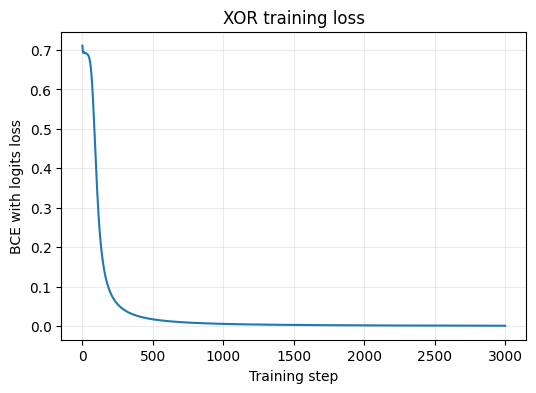

In [6]:
plt.figure(figsize=(6,4))
plt.plot(range(1, TRAINING_STEPS+1), baseline['losses'])
plt.xlabel('Training step'); plt.ylabel('BCE with logits loss')
plt.title('XOR training loss')
plt.grid(True, alpha=0.25); plt.show()

### Task 4C - Symmetry experiment

In [7]:
symmetry = train_xor(nn.Sigmoid, zero_init=True, steps=10, early_step=1)
for step, weights in symmetry['symmetry_history']:
    print(f'Step {step}:\n{weights}')
print('\nFirst-layer gradient at step 1:')
print(symmetry['early_grad'])
rows_identical = all(torch.equal(w[0], w[1]) for _, w in symmetry['symmetry_history'])
print('Hidden-layer rows remain exactly identical:', rows_identical)
assert rows_identical

Step 1:
tensor([[0., 0.],
        [0., 0.]])
Step 2:
tensor([[0., 0.],
        [0., 0.]])
Step 3:
tensor([[0., 0.],
        [0., 0.]])
Step 5:
tensor([[0., 0.],
        [0., 0.]])
Step 10:
tensor([[0., 0.],
        [0., 0.]])

First-layer gradient at step 1:
tensor([[0., 0.],
        [0., 0.]])
Hidden-layer rows remain exactly identical: True


### Task 4D - Activation experiment

In [8]:
activation_specs=[('Sigmoid',nn.Sigmoid),('Tanh',nn.Tanh),('ReLU',nn.ReLU)]
activation_results=[]
for name,cls in activation_specs:
    r=train_xor(cls)
    activation_results.append((name,r))
print(f'{"Activation":<10} {"Final loss":>12} {"4/4":>8} {"Early grad norm":>18}')
print('-'*52)
for name,r in activation_results:
    print(f'{name:<10} {r["final_loss"]:>12.6f} {str(r["predictions"]==[0,1,1,0]):>8} {r["early_grad_norm"]:>18.6f}')

Activation   Final loss      4/4    Early grad norm
----------------------------------------------------
Sigmoid        0.000694     True           0.010602
Tanh           0.000222     True           0.074817
ReLU           0.000085     True           0.130315


In [9]:
# Inspect pre-activations/activations to distinguish saturation from inactive ReLU units.
for name,r in activation_results:
    m=r['model']
    with torch.no_grad():
        pre=m.fc1(X); act=m.activation(pre)
    print(name)
    print('pre:', pre)
    print('act:', act)
    print()

Sigmoid
pre: tensor([[ -4.9644,   5.0789],
        [  4.4880,  15.8434],
        [-14.8669,  -4.9473],
        [ -5.4145,   5.8172]])
act: tensor([[6.9337e-03, 9.9381e-01],
        [9.8888e-01, 1.0000e+00],
        [3.4944e-07, 7.0528e-03],
        [4.4319e-03, 9.9703e-01]])

Tanh
pre: tensor([[-2.2625,  2.3210],
        [ 2.4023,  7.5991],
        [-7.3721, -2.4398],
        [-2.7074,  2.8383]])
act: tensor([[-0.9786,  0.9809],
        [ 0.9837,  1.0000],
        [-1.0000, -0.9849],
        [-0.9911,  0.9932]])

ReLU
pre: tensor([[-4.8917e-05,  2.6876e+00],
        [ 5.1325e+00,  5.4364e+00],
        [-5.1325e+00,  6.1989e-06],
        [ 4.6450e-05,  2.7489e+00]])
act: tensor([[0.0000e+00, 2.6876e+00],
        [5.1325e+00, 5.4364e+00],
        [0.0000e+00, 6.1989e-06],
        [4.6450e-05, 2.7489e+00]])



### Task 5 - Three-class extension

**Modification prompt:**

> Modify the previous 2-input -> 2-hidden-unit PyTorch model only in the output/loss portion for the three-class sensor task with labels `[0,1,1,2]`. Keep the hidden representation and activation unchanged. Replace the single output with three logits and use `CrossEntropyLoss`. Report the final loss, three class probabilities for all four inputs, predicted classes, and a numerical check that one probability vector sums to 1. Also verify the logit gradient identity `p - y`. Do not change the hidden architecture or use a pretrained model.

**Predictions before execution:** the final weight tensor should have shape `(3, 2)`, each example should produce 3 logits, softmax probabilities should sum to 1, and the cross-entropy logit gradient for one-hot targets should be `p - y`.


In [10]:
y_three_class = torch.tensor([0,1,1,2], dtype=torch.long)

class ThreeClassNet(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1=nn.Linear(2,2); self.fc2=nn.Linear(2,3); self.activation=activation
        nn.init.xavier_uniform_(self.fc1.weight); nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight); nn.init.zeros_(self.fc2.bias)
    def forward(self,x): return self.fc2(self.activation(self.fc1(x)))

torch.manual_seed(SEED)
model3=ThreeClassNet(nn.Sigmoid())
opt3=optim.Adam(model3.parameters(), lr=LEARNING_RATE)
loss3=nn.CrossEntropyLoss()
with torch.no_grad(): initial3=loss3(model3(X), y_three_class).item()
for _ in range(TRAINING_STEPS):
    opt3.zero_grad(); logits3=model3(X); l=loss3(logits3,y_three_class); l.backward(); opt3.step()
with torch.no_grad():
    logits3=model3(X); probs3=torch.softmax(logits3,dim=1); preds3=probs3.argmax(dim=1); final3=loss3(logits3,y_three_class).item()
print('Output weight shape:', tuple(model3.fc2.weight.shape))
print('Initial loss:', f'{initial3:.9f}')
print('Final loss:  ', f'{final3:.9f}')
print('Input      Target   P0            P1            P2            Pred')
for x_row,t,p,pred in zip(X.tolist(),y_three_class.tolist(),probs3.tolist(),preds3.tolist()):
    print(f'{x_row!s:10} {t:>6}   {p[0]:.9f}   {p[1]:.9f}   {p[2]:.9f}   {pred}')
assert tuple(model3.fc2.weight.shape)==(3,2)
assert preds3.tolist()==[0,1,1,2]

Output weight shape: (3, 2)
Initial loss: 1.076565385
Final loss:   0.000170900
Input      Target   P0            P1            P2            Pred
[0.0, 0.0]      0   0.999880075   0.000119899   0.000000026   0
[0.0, 1.0]      1   0.000074029   0.999853492   0.000072516   1
[1.0, 0.0]      1   0.000067527   0.999841332   0.000091054   1
[1.0, 1.0]      2   0.000001178   0.000257353   0.999741495   2


In [11]:
# Probability normalization, constant-shift stability, and p-y gradient check.
idx=1
prob=probs3[idx]
print('Probability vector:', prob.tolist())
print('Sum:', f'{prob.sum().item():.12f}')
shifted=torch.softmax(logits3[idx]+100.0,dim=0)
print('Max difference after +100 shift:', torch.max(torch.abs(prob-shifted)).item())

single_logits=logits3[idx].detach().clone().requires_grad_(True)
target=y_three_class[idx].reshape(1)
sl=nn.CrossEntropyLoss(reduction='none')(single_logits.reshape(1,-1),target)[0]
sl.backward()
with torch.no_grad():
    p=torch.softmax(single_logits.detach(),dim=0)
    one_hot=torch.nn.functional.one_hot(target[0],num_classes=3).to(p.dtype)
    expected=p-one_hot
print('Autograd grad:', single_logits.grad.tolist())
print('p - y:        ', expected.tolist())
print('Max gradient difference:', torch.max(torch.abs(single_logits.grad-expected)).item())
assert np.isclose(prob.sum().item(),1.0,atol=1e-7)
assert torch.allclose(prob,shifted,atol=1e-6,rtol=1e-6)
assert torch.allclose(single_logits.grad, expected, atol=1e-6, rtol=1e-6)

Probability vector: [7.402920891763642e-05, 0.9998534917831421, 7.251612260006368e-05]
Sum: 1.000000000000
Max difference after +100 shift: 4.220055416226387e-10
Autograd grad: [7.402917981380597e-05, -0.00014650821685791016, 7.251609349623322e-05]
p - y:         [7.402920891763642e-05, -0.00014650821685791016, 7.251612260006368e-05]
Max gradient difference: 2.9103830456733704e-11


### Notebook endpoint

All required numerical experiments have been executed and validated. Written explanations and the seven reflection answers are in the accompanying PDF report.